In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [11]:
df=pd.read_csv(r"C:\Users\RAJDEEP\Downloads\economic_index.csv")

In [12]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [14]:
df.drop(columns=['Unnamed: 0','year','month'],  inplace=True)

In [15]:
df

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


In [16]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

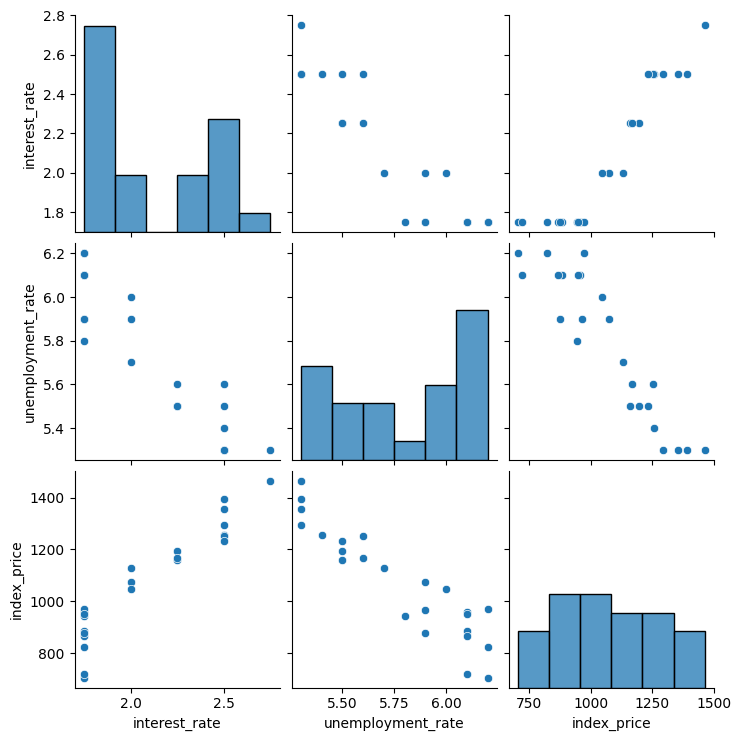

In [17]:
#visualization
import seaborn as sns
sns.pairplot(df)

In [18]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0.5, 0, 'interest rate')

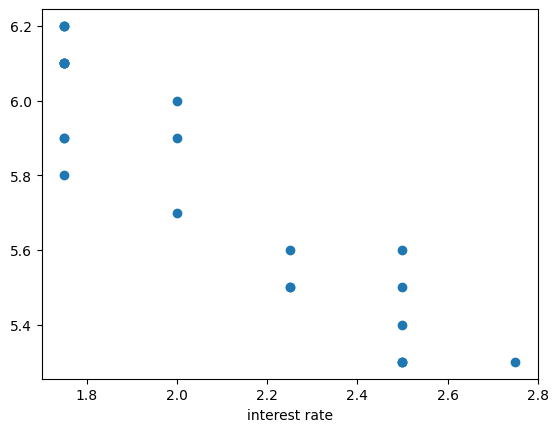

In [21]:
plt.scatter(df['interest_rate'],df['unemployment_rate'])
plt.xlabel('interest rate')

In [24]:
#independent and dependant features
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [26]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [ ]:
from sklearn.model_selection import train_test_split
x_t,x_test,y_t,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

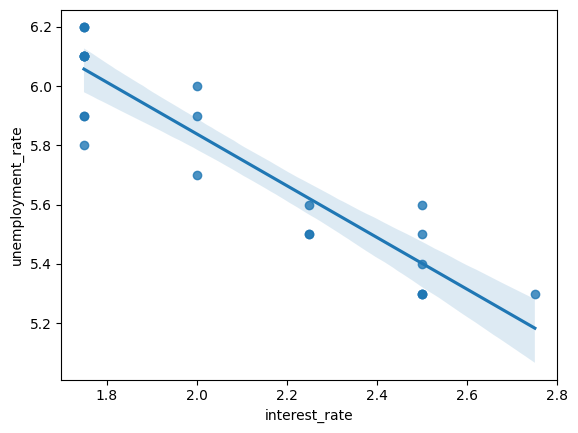

In [37]:
import seaborn as sns
sns.regplot(x=df['interest_rate'],y=df['unemployment_rate'])

In [38]:
from sklearn.preprocessing import StandardScaler


In [40]:
scaler=StandardScaler()
x_t=scaler.fit_transform(x_t)
x_test=scaler.fit_transform(x_test)

In [41]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [42]:
regression.fit(x_t,y_t)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 86.63,-114.05]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1059
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[6.04,1.25]"


In [ ]:
# cross validation
from sklearn.model_selection import cross_val_score
valid_score=cross_val_score(regression,x_t,y_t, scoring='neg_mean_squared_error',cv=3)

In [47]:
np.mean(valid_score)

np.float64(-5674.031667186762)

In [49]:
#prediction
y_pred=regression.predict(x_test)

In [51]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print(mse)
print(mae)

5952.207497480526
64.7472210563656


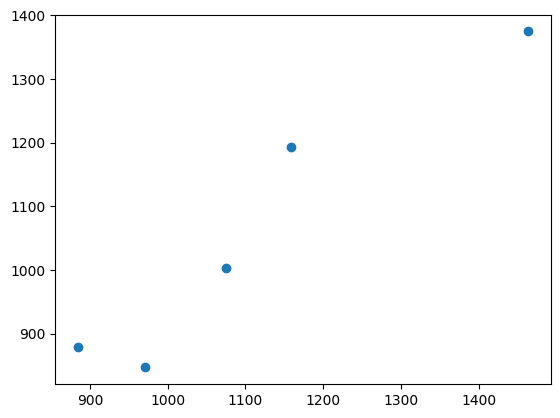

In [52]:
plt.scatter(y_test,y_pred)

In [53]:
residuals=y_test-y_pred

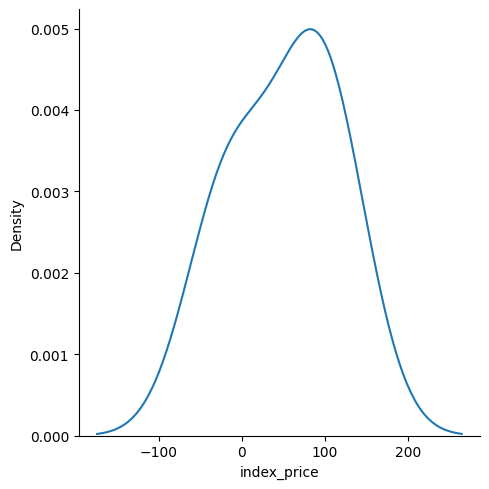

In [55]:
sns.displot(residuals,kind='kde' )

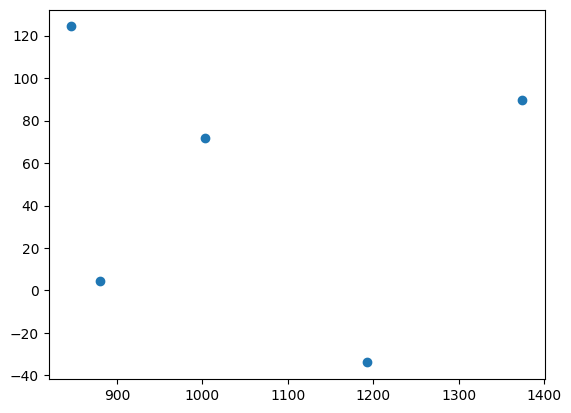

In [56]:
#scatter plot  w.r.t pred and residuals
plt.scatter(y_pred,residuals)

In [58]:
%pip install statsmodels


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.4 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.5 MB 1.1 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.5 MB 1.1 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.5 MB 856.3 kB/s eta 0:00:10
   ---- ----------------------------------- 1.0/9.5 MB 856.3 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/9.5 MB 778.5 kB/s eta 0:00:11
   ----- ---------------------------------- 1.3/9.5 MB 778.5 kB/s eta 0:00:11
   ------ --------------------------------- 1.6/9.5 MB 805.3 kB/s eta 0:00:10
   ------- -------------------------------- 1.8/9.5 MB 825.1 kB/s eta 0:00:10
   -------- ------------------------------- 2.1/9.5 MB 867.2 kB/s eta 0:00:09
   --------- ------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
import statsmodels.api as sm 
model=sm.OLS(y_t,x_t).fit()
pred=model.predict(x_test)
print(pred)

[ 133.49963159 -212.73017933  315.11450745 -179.80719232  -56.07676738]
